# PCA Chronology

Record of the re-analysis of *Determining Conversational Styles at Scale* (Switchboard; per-utterance features → PCA → GMM → two-style HC/HI claim). Each section documents one stage of the work, in order.

## 1. Replicating the paper's pipeline — diagnosis of the legacy extractors

Step one was re-running the paper's extraction from `legacy/ICNLP/`. Nearly every extractor was buggy. Implementation bugs are listed per feature; *(validity)* marks logical flaws that undermine the output even where the code runs.

### Shared infrastructure (affects every feature)

- **Utterance Quantity**: Unknown previous filtering yielded different total utterances. Using swb cleaned yeilded ~214k. Could not replicate paper's 138k.
- **Conversation ID = directory prefix** (`SwitchboardReader.py`): the 3-digit folder (`409/`) is treated as one conversation, pooling ~10 unrelated phone calls. Utterances are time-sorted and chained as predecessors **across calls**. *(validity: every predecessor-based feature can compare different conversations)*
- **Transcript/audio mismatch**: wavs were cut at line numbers of the *original* transcripts; text is fetched by line number from the *cleaned* transcripts, which drop `[silence]`/`[noise]` lines. After the first such line, a row's text and audio are different utterances.
- **Silent parse failures** (`Utterance.py`): bare `except: pass` — malformed lines become "valid" empty utterances at time 0–0.
- **Reader off-by-one** (`has_next_utterance`): the last conversation is mishandled; a conversation with no valid utterance crashes the iterator.
- **Row order**: rows appended at `df.loc[-1]` with index shifting, then `sort_index()` (authors' own comment: "Not sure this is valid") — output order is reversed relative to read order.

### Per feature (paper Table 2)

**Turn gap** — `FETurnGap.py`
- "Previous" = chronological predecessor regardless of speaker: same-speaker continuations and listener backchannels count as turn ends. *(validity: not a turn measure)*
- First utterance has no predecessor → returns its absolute start time as the "gap".
- With pooled conversations, gaps span unrelated calls → the paper's physically impossible **−3.9 s mean gap in both groups**, on the highest-loading PC1 feature.

**Token count** — `FETokenCount.py`
- Annotation brackets count as words: `[noise]` → token `noise`.

**Word rate** — `FEWordRate.py` *and* `FETokenCount.py`
- Two different definitions (whitespace split vs gensim tokenize) ship under the same column name; unclear which produced the paper's numbers.
- Denominator is the trans-line duration, which includes silence padding → deflated rates; bracket tokens inflate the numerator.

**Self- / prev-repetitions** — `FERepeats.py`
- Counts all repeated pairs: a word said *k* times adds *k(k−1)/2*. A raw, quadratically length-confounded count, not a rate. *(validity: its PC1 loading is partly utterance length)*
- Prev-repetitions compares against the cross-speaker, possibly cross-conversation predecessor.
- Conflates disfluent repair ("I- I- I") with Tannen's rhetorical repetition; lemmatizes without POS; brackets included.

**Repetition rate** — `FERepetition.py`
- Median 0 in both groups (zero-inflated); the paper notes this, then t-tests means anyway.
- Brackets counted; case-folding is the only normalization.

**Syllable rate** — `FESyllableRate.py` (+ `.py.old`)
- The committed file cannot run: `self.word_re` is used but never defined (`AttributeError` on every call). It also computes syllables per *word*, while the paper reports a "rate".
- The shipped values (≈3.1) match the `.py.old` version: syllables/sec from vowel-run counting over raw tokens (brackets included), divided by silence-padded duration. *(validity: which code produced the paper's column is unknowable)*
- Node subprocess failures silently return 0 syllables.

**Filler word rate** — `FEFillerWords.py`
- Multi-word fillers (`you know`, `i mean`, `i guess`) are compared against single tokens → can never match; silently never counted.
- `so`, `well`, `like` counted in every syntactic role (conjunction, adverb, verb).
- *(validity: filled pauses and discourse markers — opposite involvement signs in Tannen's framework — are merged into one rate)*

**Pronoun rate** — `FEPronounRate.py`
- No zero-token guard → `ZeroDivisionError` on empty parses.
- Brackets are tokenized into the denominator.

**Loudness mean / std / range** — `features.py` / `FELoud.py`
- RMS over the whole slice including silence padding → stats diluted in proportion to padding.
- Audio implicitly resampled to 22,050 Hz; range = max−min of raw frames, driven by single-frame outliers.

**Pitch mean / std / range** (extracted, then dropped) — `features.py` / `FELoud.py` vs `FEGen.py`
- Unvoiced or failed tracking returns `0.0, 0.0, 0.0` — "no measurement" stored as a real value.
- Two incompatible definitions under identical column names: pyin on resampled audio vs piptrack on native-rate audio.
- *(validity: pitch was dropped from the PCA because it "creates far less well defined conversational style groups" — features selected for the structure they produce)*

### TLDR;

- `aligned_acoustic_linguistic.csv` is a positional cbind of three tables in three different row orders (one a different length; 77,682 rows silently truncated) → essentially every row pairs acoustic and linguistic features from different utterances. The producing notebook (`fix feature matrix.ipynb`) printed the contradiction in its own output and saved anyway.

**Bottom line:** the paper's three top-loading PC1 features (turn gap, token count, repetitions) are respectively cross-conversation, padding/bracket-inflated, and length-confounded — and the matrix joining them to the acoustics is row-scrambled. The PCA ran on artifacts.

## 2. Replicating the paper's result

With the extractors rebuilt, the next step was to ask whether the paper's headline finding — two conversational "styles" — survives. I followed the paper's own analysis recipe on the rebuilt feature table (`merge_test.csv`):

1. Take the 11 paper-aligned features (Table 1, minus pitch).
2. **Row-normalize** each utterance, then run PCA.
3. Fit a Gaussian Mixture Model (GMM) to the first component (PC0) and let silhouette analysis pick the number of clusters.

The result reproduces the paper: PC0 holds ~58% of the variance, silhouette picks **k = 2**, and PC0 shows the same two-bump shape read as "High Considerateness" vs "High Involvement."

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

feature_cols = [
    "token_count", "loudness mean", "loudness std", "loudness range",
    "Turn Gap", "word_rate", "syllable_rate", "Pronouns per Second",
    "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
    "Filler Words per Second",
]

df = (pd.read_csv("../utterances_v2/merge_test.csv")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=feature_cols))

pca = PCA(n_components=len(feature_cols))
df["pc0"] = pca.fit_transform(normalize(df[feature_cols].values))[:, 0]
print(f"{len(df):,} utterances  |  PC0 holds {pca.explained_variance_ratio_[0]:.1%} of variance")

212,210 utterances  |  PC0 holds 57.8% of variance


### Loadings — what PC0 is made of

In [2]:
loadings = pd.Series(pca.components_[0], index=feature_cols)
print(loadings.reindex(loadings.abs().sort_values(ascending=False).index)
             .to_string(float_format="%+.4f"))

Turn Gap                            +0.9050
token_count                         +0.4066
Repetitions In Current Utterance    +0.1055
Repetitions In Previous Utterance   +0.0528
syllable_rate                       -0.0287
word_rate                           -0.0258
Pronouns per Second                 +0.0172
loudness range                      -0.0022
Filler Words per Second             +0.0010
loudness std                        -0.0007
loudness mean                       -0.0004


### PC0 distribution and best-fit GMM

Left: the raw PC0 histogram. Right: the best-k GMM (**k = 2** by silhouette) overlaid — two Gaussian components, the paper's "two styles."

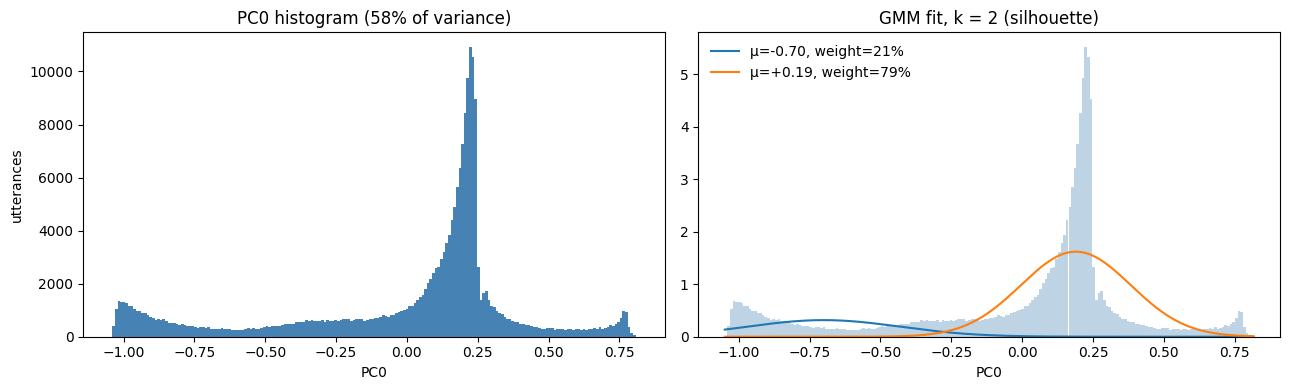

In [3]:
gmm = GaussianMixture(n_components=2, random_state=0).fit(df[["pc0"]].values)
mu, sd, w = gmm.means_.ravel(), np.sqrt(gmm.covariances_.ravel()), gmm.weights_

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df["pc0"], bins=200, color="steelblue")
ax[0].set(title=f"PC0 histogram ({pca.explained_variance_ratio_[0]:.0%} of variance)",
          xlabel="PC0", ylabel="utterances")

ax[1].hist(df["pc0"], bins=200, density=True, color="steelblue", alpha=0.35)
xs = np.linspace(df["pc0"].min(), df["pc0"].max(), 1000)
for i in np.argsort(mu):
    ax[1].plot(xs, w[i] / (sd[i] * np.sqrt(2*np.pi)) * np.exp(-0.5*((xs-mu[i])/sd[i])**2),
               label=f"\u03bc={mu[i]:+.2f}, weight={w[i]:.0%}")
ax[1].set(title="GMM fit, k = 2 (silhouette)", xlabel="PC0")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Fixing the scaling — and where the "two styles" went

Section 2's bimodality came from row-normalization. Here we replace it with per-column **standardization** and re-run the identical PCA → GMM pipeline, then iterate on the scaling until the distribution is trustworthy. (Standardize = z-score each column: mean 0, variance 1, so no feature wins PC0 just for having a wider range.)

Dr. Brizan commented that this was the histogram he was more or less expecting when he initally did the work. In retrospect, to me this is pretty near a normal distrbution with some weird skewing going on and some very short peaks. GMM cannot fit less than 2 as it is a gaussian mixture by definition, so not ideal. 

This is the part where I started to get curious about why exactly turn gap dominated the PCA. I started to think about examining different "feature recipies". I was trying to lead with theory in an attempt to pry out another clear bimodal to help support the original work. This led me to discover standardization vs. normalization. 

Normalization (here, sklearn normalize = L2) scales each row to unit length — it rescales every utterance by its own magnitude, mixing incommensurable units (seconds, counts, rates) within the row.

Standardization (z-score) rescales each column: subtract the feature's mean, divide by its std → every feature gets mean 0, variance 1.

Why standardization is a sensible choice here:

- PCA maximizes variance, and variance is unit-dependent. The feature with the widest raw spread dominates PC0 regardless of whether it carries any real signal. Turn gap's range dwarfs the others → it hijacks the axis.
- Standardizing puts all features on equal footing (variance 1), so PC0 reflects covariance structure (how features move together), not arbitrary units.
- Row-normalization doesn't fix this at all — it never equalizes across features, it just divides each row by its own norm.

So, standardize columns so no feature wins PC0 just for being measured in bigger numbers.

### Part A — StandardScaler

With every feature at variance 1, **turn gap no longer hijacks PC0**. PC0 drops to ~44% (was 58%) and now loads *evenly* across all 11 features (~0.3–0.4 each) — a broad rate/intensity axis, not one feature.

**Why k jumps to a weird 5:** silhouette picks k=5, but it is spurious — GMM over-segmenting one smooth, skewed hump. BIC shows **no elbow** (it keeps improving all the way to k=10), and the KDE collapses to a single mode at a wider bandwidth. The heavy right tails (loudness, repetitions skewed up to +5) make fake shoulders that the GMM carves into "clusters."

PC0 holds 43.9% of variance

word_rate                           +0.3947
syllable_rate                       +0.3856
token_count                         +0.3826
Pronouns per Second                 +0.3248
loudness mean                       +0.3179
loudness range                      +0.3113
Repetitions In Current Utterance    +0.3014
loudness std                        +0.2743
Repetitions In Previous Utterance   +0.2001
Filler Words per Second             +0.1462
Turn Gap                            +0.1347


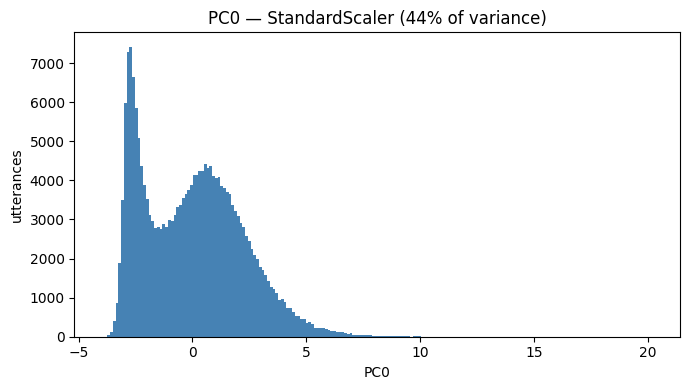

In [4]:
from sklearn.preprocessing import StandardScaler

Xa = StandardScaler().fit_transform(df[feature_cols].values)
pca_a = PCA(n_components=len(feature_cols)).fit(Xa)
pc0_a = pca_a.transform(Xa)[:, 0]

print(f"PC0 holds {pca_a.explained_variance_ratio_[0]:.1%} of variance\n")
la = pd.Series(pca_a.components_[0], index=feature_cols)
print(la.reindex(la.abs().sort_values(ascending=False).index).to_string(float_format="%+.4f"))

plt.figure(figsize=(7, 4))
plt.hist(pc0_a, bins=200, color="steelblue")
plt.title(f"PC0 — StandardScaler ({pca_a.explained_variance_ratio_[0]:.0%} of variance)")
plt.xlabel("PC0"); plt.ylabel("utterances"); plt.tight_layout(); plt.show()

### Part B — RobustScaler, and its drawback


StandardScaler is itself pulled by those heavy tails. We tried **RobustScaler** (center on the median, scale by the IQR) to blunt outliers. It pushed PC0 back to ~62% and returned k=2 — but the second "cluster" is a tiny weight-0.28, std-6.5 blob: the outliers it *still* couldn't tame, not a style. The lesson: the problem is **skew**, not the choice of scaler. So we fix the skew at the source → Part C.

### Part C — winsorize + log1p, then standardize

**Method:** clip each feature to its [1%, 99%] range (winsorize) to kill outliers; `log1p` the skewed non-negative counts/rates; leave Turn Gap (it has negative = overlap values) winsorized only; then z-score.

**C1** — skew collapses toward 0 (prev-repetitions +5.03 → +1.44, token count +1.18 → +0.02). **C3** — PC0 is now a clean, near-symmetric distribution, and silhouette returns to **k=2**. This is the cleanest version of the paper's pipeline — so the two-bump claim gets a fair test.

feature                             skew before  skew after
token_count                                1.18        0.02
loudness mean                              2.18        1.59
loudness std                               2.15        1.54
loudness range                             2.08        1.55
Turn Gap                                  -0.70       -0.86
word_rate                                  0.17       -0.27
syllable_rate                              0.09       -0.40
Pronouns per Second                        0.72        0.21
Repetitions In Current Utterance           3.71        1.04
Repetitions In Previous Utterance          5.03        1.44
Filler Words per Second                    1.75        1.14


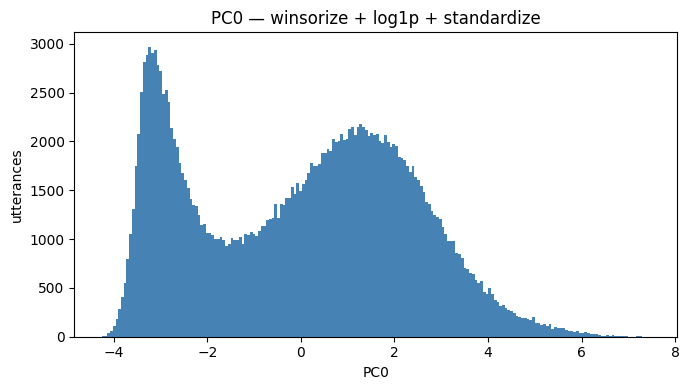

In [5]:
from scipy.stats import skew

log_cols = ["token_count", "word_rate", "syllable_rate", "Pronouns per Second",
            "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
            "Filler Words per Second"]

def transform(frame):
    Xt = frame[feature_cols].copy()
    for c in feature_cols:                       # winsorize to [1%, 99%]
        lo, hi = Xt[c].quantile(0.01), Xt[c].quantile(0.99)
        Xt[c] = Xt[c].clip(lo, hi)
    for c in log_cols:                           # log1p the skewed non-negative cols
        Xt[c] = np.log1p(Xt[c])
    return Xt

Xt = transform(df)
print(f"{'feature':34s}{'skew before':>13s}{'skew after':>12s}")
for c in feature_cols:
    print(f"{c:34s}{skew(df[c]):>13.2f}{skew(Xt[c]):>12.2f}")

Xc = StandardScaler().fit_transform(Xt.values)
pca_c = PCA(n_components=len(feature_cols)).fit(Xc)
pc0_c = pca_c.transform(Xc)[:, 0]

plt.figure(figsize=(7, 4))
plt.hist(pc0_c, bins=200, color="steelblue")
plt.title("PC0 — winsorize + log1p + standardize")
plt.xlabel("PC0"); plt.ylabel("utterances"); plt.tight_layout(); plt.show()

### The k=2 looks real — but the t-test that "confirms" it is circular

Welch t-tests between the two clusters come back hugely significant. That proves nothing: PC0 is ≈ the sum of the 11 features, we cluster on PC0, then t-test those **same** features (double-dipping). Significance is guaranteed by construction. So the t-test fails as evidence — we stopped trusting the split and asked what is actually *in* the clusters.

### Part E — the bimodality is backchannels

The low-PC0 cluster is **~98% one/two-token utterances**: *yeah, um-hum, uh-huh, right, oh*. It is backchannels vs. real speech, not High-Considerateness vs. High-Involvement. We strip every pure-backchannel utterance and re-run the Part-C pipeline.

**E4 result:** PC0 becomes **unimodal** — 1 KDE mode at every bandwidth, skew collapses toward 0. Forcing k=2 anyway only separates **short (median 3 tokens) vs. long (median 19)** utterances: length, not style.

backchannels removed: 53,570  |  substantive utterances: 158,640
PC0 skew = -0.32


  KDE bw=0.15: 1 mode(s)


  KDE bw=0.25: 1 mode(s)


  KDE bw=0.4: 1 mode(s)


  KDE bw=0.6: 1 mode(s)

force k=2 → token_count median per cluster:
_c
0     3.0
1    19.0


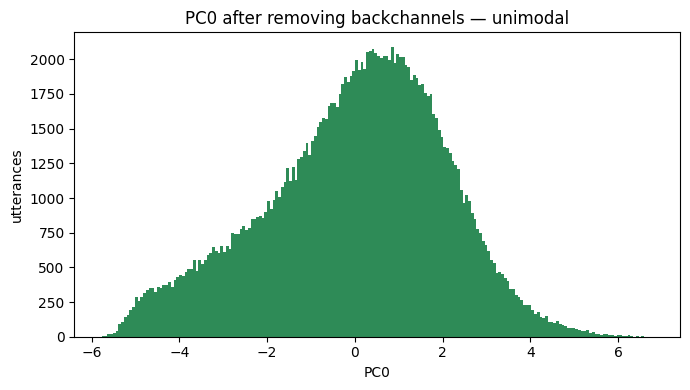

In [6]:
import string
from scipy.stats import gaussian_kde

BC = {"yeah","yea","yep","yup","yes","ya","yah","uh-huh","uhhuh","huh-uh","um-hum",
      "umhum","mm-hmm","mm-hm","mmhm","mhm","m-hm","mm","mmm","hm","hmm","hmmm",
      "hum","huh","uh","um","er","erm","ah","oh","ooh","aw","okay","ok","right",
      "sure","wow","gosh"}

def is_backchannel(t):
    toks = [w.strip(string.punctuation).lower() for w in str(t).split()]
    toks = [w for w in toks if w]
    return len(toks) > 0 and all(w in BC for w in toks)

sub = df[~df["Transcript"].apply(is_backchannel)].copy()
Xs = StandardScaler().fit_transform(transform(sub).values)
pca_s = PCA(n_components=len(feature_cols)).fit(Xs)
pc0_s = pca_s.transform(Xs)[:, 0]

def n_modes(x, bw):
    kde = gaussian_kde(x, bw_method=bw)
    xs = np.linspace(x.min(), x.max(), 1000); d = kde(xs)
    pk = (d[1:-1] > d[:-2]) & (d[1:-1] > d[2:]) & (d[1:-1] > 0.01 * d.max())
    return int(pk.sum())

print(f"backchannels removed: {len(df) - len(sub):,}  |  substantive utterances: {len(sub):,}")
print(f"PC0 skew = {skew(pc0_s):+.2f}")
for bw in [0.15, 0.25, 0.4, 0.6]:
    print(f"  KDE bw={bw}: {n_modes(pc0_s, bw)} mode(s)")

g2 = GaussianMixture(n_components=2, random_state=0).fit(pc0_s.reshape(-1, 1))
sub["_c"] = g2.predict(pc0_s.reshape(-1, 1))
print("\nforce k=2 → token_count median per cluster:")
print(sub.groupby("_c")["token_count"].median().to_string())

plt.figure(figsize=(7, 4))
plt.hist(pc0_s, bins=200, color="seagreen")
plt.title("PC0 after removing backchannels — unimodal")
plt.xlabel("PC0"); plt.ylabel("utterances"); plt.tight_layout(); plt.show()

**Conclusion (Part E):** the "two conversational styles" split is an artifact of **backchannels + skew**, not a real bimodality. The underlying style dimension is *continuous* — consistent with Tannen's *continuum between two poles*, but the discrete two-cluster claim does not survive. And style is a property of a *speaker*, not a one-word utterance → the real test is a **speaker-level** analysis (next section).

## 4. The real test — do *speakers* split into two styles?

Sections 2–3 worked one utterance at a time. But a conversational *style* belongs to a **speaker**, not a one-word utterance. So the proper test of "two styles" is whether **speakers** fall into two groups or spread along one continuum.

**Method, in plain terms:**
1. Identify each speaker from the filename (`sw2001A` = conversation 2001, side A — there are two speakers per call).
2. Drop backchannel utterances (the *yeah / uh-huh* tokens that faked the bimodality in Section 3), then average each speaker's remaining "substantive" utterances into a single feature profile.
3. Keep only speakers with **≥ 20** substantive utterances, so each average is stable.
4. Standardize the profiles across speakers and run PCA — now **one point = one speaker**.

In [7]:
import pandas as pd, numpy as np, string, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import skew, gaussian_kde, ttest_ind
from scipy.signal import find_peaks

feature_cols = ["token_count", "loudness mean", "loudness std", "loudness range", "Turn Gap",
                "word_rate", "syllable_rate", "Pronouns per Second",
                "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
                "Filler Words per Second"]
demo_cols = ["Gender", "Region", "Generation", "Education", "Year Born"]

sp = pd.read_csv("../utterances_v2/paper_aligned_standardized_PCA.csv",
                 usecols=["Utterance File Name", "Transcript"] + feature_cols + demo_cols)
sp["speaker"] = sp["Utterance File Name"].str.extract(r"(sw\d+[AB])")
print(f"utterances: {len(sp):,}  |  distinct speakers: {sp['speaker'].nunique():,}")

BC = {"yeah","yea","yep","yup","yes","ya","yah","uh-huh","uhhuh","huh-uh","um-hum",
      "umhum","mm-hmm","mm-hm","mmhm","mhm","m-hm","mm","mmm","hm","hmm","hmmm",
      "hum","huh","uh","um","er","erm","ah","oh","ooh","aw","okay","ok","right",
      "sure","wow","gosh"}

def is_backchannel(t):
    toks = [w.strip(string.punctuation).lower() for w in str(t).split()]
    toks = [w for w in toks if w]
    return len(toks) > 0 and all(w in BC for w in toks)

sp["is_bc"] = sp["Transcript"].apply(is_backchannel)
subu = sp[~sp["is_bc"]]
spk = subu.groupby("speaker")[feature_cols].mean()
spk["n_sub"]   = subu.groupby("speaker").size()
spk["bc_rate"] = sp.groupby("speaker")["is_bc"].mean()
for d in demo_cols:
    spk[d] = sp.groupby("speaker")[d].first()

print(f"substantive utterances/speaker: median {int(spk['n_sub'].median())}, "
      f"min {spk['n_sub'].min()}, max {spk['n_sub'].max()}")
spk = spk[spk["n_sub"] >= 20].copy()
print(f"speakers retained (>= 20 substantive utterances): {len(spk):,}")

utterances: 212,210  |  distinct speakers: 3,988


substantive utterances/speaker: median 36, min 1, max 137
speakers retained (>= 20 substantive utterances): 3,680


### Speaker PC0 — one axis, no second hump

PC0 holds ~40% of the variance and loads on **token count, repetitions, word rate, syllable rate** — a single "verbal intensity / productivity" axis (talkative, fast, repetitive speakers at one end; terse speakers at the other). Turn gap is again a weak contributor. The histogram is one skewed hump, not two.

PC0 holds 39.5% of variance

token_count                         +0.4077
Repetitions In Current Utterance    +0.3991
word_rate                           +0.3972
syllable_rate                       +0.3848
Pronouns per Second                 +0.3050
Repetitions In Previous Utterance   +0.3017
loudness mean                       +0.2251
loudness range                      +0.2213
loudness std                        +0.2028
Filler Words per Second             +0.1792
Turn Gap                            +0.1083


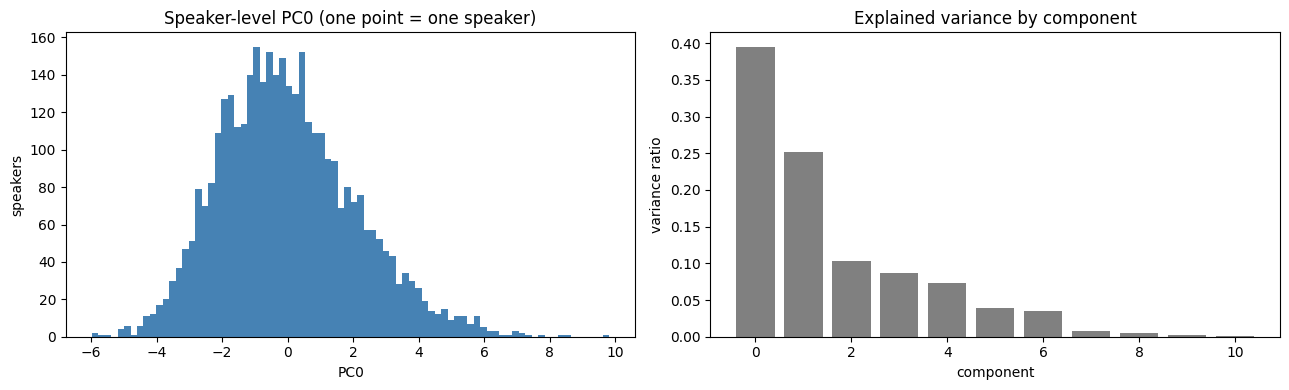

In [8]:
Xs = StandardScaler().fit_transform(spk[feature_cols].values)
pca_spk = PCA(n_components=len(feature_cols)).fit(Xs)
pc0 = pca_spk.transform(Xs)[:, 0]
spk["pc0"] = pc0

print(f"PC0 holds {pca_spk.explained_variance_ratio_[0]:.1%} of variance\n")
ls = pd.Series(pca_spk.components_[0], index=feature_cols)
print(ls.reindex(ls.abs().sort_values(ascending=False).index).to_string(float_format="%+.4f"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(pc0, bins=80, color="steelblue")
ax[0].set(title="Speaker-level PC0 (one point = one speaker)", xlabel="PC0", ylabel="speakers")
ax[1].bar(range(len(feature_cols)), pca_spk.explained_variance_ratio_, color="gray")
ax[1].set(title="Explained variance by component", xlabel="component", ylabel="variance ratio")
plt.tight_layout(); plt.show()

### One hump or two? — KDE, silhouette, BIC

Two checks, read together. **KDE mode count** (a smoothed histogram; count the peaks) at several smoothing levels. **Silhouette / BIC** for k clusters — but mind the trap: silhouette can favor k≥2 by slicing one hump, and BIC can prefer 2 Gaussians just to fit *skew*, not a real second mode. So we also size the BIC gain against the (huge) utterance-level backchannel split.

In [9]:
print(f"PC0 skew = {skew(pc0):+.3f}")
grid = np.linspace(pc0.min(), pc0.max(), 2000)
for bw in [0.15, 0.25, 0.40, 0.60]:
    d = gaussian_kde(pc0, bw_method=bw)(grid)
    pk, _ = find_peaks(d, prominence=d.max() * 0.01)
    print(f"  KDE bw={bw}: {len(pk)} mode(s)")

X1 = pc0.reshape(-1, 1)
sil = {k: round(silhouette_score(X1, GaussianMixture(k, random_state=0).fit(X1).predict(X1),
                                 random_state=0), 3) for k in range(2, 8)}
bic = {k: round(GaussianMixture(k, random_state=0).fit(X1).bic(X1)) for k in range(1, 8)}
print("\nsilhouette:", sil, "-> best k =", max(sil, key=sil.get))
print(f"BIC(k=2) - BIC(k=1) = {bic[2]-bic[1]:+d}   "
      f"(utterance-level backchannel split was ~ -53,000)")

PC0 skew = +0.485
  KDE bw=0.15: 1 mode(s)
  KDE bw=0.25: 1 mode(s)
  KDE bw=0.4: 1 mode(s)
  KDE bw=0.6: 1 mode(s)



silhouette: {2: 0.567, 3: 0.538, 4: 0.525, 5: 0.521, 6: 0.516, 7: 0.524} -> best k = 2
BIC(k=2) - BIC(k=1) = -110   (utterance-level backchannel split was ~ -53,000)


### Even if forced into 2 groups, it's just terse vs. talkative

Forcing k=2 splits speakers only by **how much they say** (token count 14 vs. 21), not into distinct styles. And unlike Section 3, PC0 barely tracks backchannel rate (r ≈ −0.11) or sheer number of utterances (r ≈ −0.04) — so this axis is a *real* speaker trait, just a **continuous** one, not the earlier artifact.

In [10]:
g2 = GaussianMixture(n_components=2, random_state=0).fit(X1)
spk["lab"] = g2.predict(X1)
for L in spk.groupby("lab")["word_rate"].mean().sort_values().index:
    g = spk[spk["lab"] == L]
    print(f"group {L}: n={len(g):>4d} | token_count={g['token_count'].mean():5.2f} | "
          f"word_rate={g['word_rate'].mean():.2f} | bc_rate={g['bc_rate'].mean():.2f}")
print(f"\nPC0 vs backchannel rate: r={np.corrcoef(pc0, spk['bc_rate'])[0,1]:+.3f}")
print(f"PC0 vs # utterances:     r={np.corrcoef(pc0, spk['n_sub'])[0,1]:+.3f}")

group 1: n=2465 | token_count=14.14 | word_rate=2.48 | bc_rate=0.24
group 0: n=1215 | token_count=21.02 | word_rate=2.95 | bc_rate=0.23

PC0 vs backchannel rate: r=-0.109
PC0 vs # utterances:     r=-0.039


### Demographics *along* the continuum

Since PC0 is one continuous axis, we compare its **mean by demographic group** instead of forcing clusters. PC0 was not built from demographics, so testing it across (e.g.) gender is legitimate — not the circular double-dipping of Section 3.

**Gender:** women −0.32, men +0.36 (Cohen d ≈ −0.33).

**Region** (low → high, mean speaker PC0): western −0.43 · mixed −0.24 · south_midland −0.17 · northern −0.00 · north_midland +0.19 · southern +0.30 · new_england +0.38 · **nyc +0.83 (highest)**. NYC is its own Switchboard dialect-region code — a distinct group, *not* part of New England.

Caveats are listed in the code cell below.

In [11]:
# CAVEATS:
#  - Pseudoreplication: each 'speaker' is a conversation-side; with ~9 calls per caller,
#    repeated callers are counted as independent. A caller-level re-test is future work.
#  - 'Highest on PC0' = highest verbal intensity/productivity (more, faster, more repetitive
#    talk) -- NOT 'most regionally distinctive'. It is a position along the continuum.
#  - Region 'unk' and speakers with <20 substantive utterances are excluded.
#  - Region is a complete enumeration: every dialect code with retained speakers is shown
#    (nyc and new_england are separate groups).

from IPython.display import display

# One table per demographic, emitted as its own output so no rows are collapsed.
for dcol in ["Gender", "Generation", "Region", "Education"]:
    tab = (spk.groupby(dcol)["pc0"].agg(["mean", "count"])
              .sort_values("mean").round(3))
    print(f"mean speaker PC0 by {dcol}  ({len(tab)} groups, all shown):")
    display(tab)

gtop = spk["Gender"].value_counts().head(2).index.tolist()
a = spk[spk["Gender"] == gtop[0]]["pc0"]; b = spk[spk["Gender"] == gtop[1]]["pc0"]
t, p = ttest_ind(a, b, equal_var=False)
dd = (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
print(f"PC0 {gtop[0]} vs {gtop[1]}: Welch p={p:.2e}, Cohen d={dd:+.3f}")

mean speaker PC0 by Gender  (2 groups, all shown):


,mean,count
Gender,,
female,-0.322,1943
male,0.360,1737


mean speaker PC0 by Generation  (4 groups, all shown):


,mean,count
Generation,,
GI,-1.223,25
Generation_X,-0.251,519
Silent,-0.030,1042
Baby_Boomer,0.092,2094


mean speaker PC0 by Region  (8 groups, all shown):


,mean,count
Region,,
western,-0.430,533
mixed,-0.239,225
south_midland,-0.170,1179
northern,-0.002,418
north_midland,0.189,534
southern,0.296,377
new_england,0.379,157
nyc,0.827,257


mean speaker PC0 by Education  (5 groups, all shown):


,mean,count
Education,,
1,-0.372,246
2,-0.164,2200
9,0.127,53
0,0.368,24
3,0.377,1157


PC0 female vs male: Welch p=3.48e-23, Cohen d=-0.330


**Conclusion (speaker level):** KDE shows a single mode at every smoothing level, and the BIC(k=2) gain (≈ −110) is trivial next to the utterance-level backchannel split (≈ −53,000). **Speakers do not separate into two styles** — PC0 is one continuous "verbal intensity / productivity" axis, with turn gap again weak. This agrees with the utterance-level result and supports reframing the finding as **a continuum between Tannen's two poles**, not two discrete populations, with demographic effects reported as shifts *along* that continuum.

## What i'm working on now:
After this speaker level analysis, I redirected focus on leading with theory again to try to best support the paper. Which has led me down the path of the (incomplete and buggy) orthogonal feature extractors. Adding more timing features, not volume of speech features. These were derived from modifications of the features found in tannen_feature_map. I optimized for most important tannen features like machine gun questions, within utterance pauses, etc. These features are incomplete, and a WIP. 
I took this route to broaden the scope of the dimensions and capture as much essence of a conversation as possible.